# import libraries

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.cluster import (KMeans,AffinityPropagation, MeanShift, SpectralClustering,
AgglomerativeClustering, DBSCAN, OPTICS, Birch)
from sklearn.mixture import GaussianMixture
import warnings

In [3]:
warnings.filterwarnings('ignore')

# load data

In [6]:
data= load_iris()
X= StandardScaler().fit_transform(data.data)

# clustering models

In [13]:
models= [
    ('KMeans',KMeans(n_clusters=3,n_init=10, random_state=42)),
    ('Affinity Propagation', AffinityPropagation(damping=0.9)),
    ('MeanShift',MeanShift()),
    ('Spectral Clustering', SpectralClustering(n_clusters=3, affinity='nearest_neighbors')),
    ('Agglomerative (Ward)', AgglomerativeClustering(n_clusters=3)),
    ('Agglomerative (Complete)', AgglomerativeClustering(n_clusters=3, linkage='complete')),
    ('DBSCAN', DBSCAN(eps=0.5, min_samples=5)),
    ('OPTICS', OPTICS(min_samples=5)),
    ('BIRCH' , Birch(n_clusters=3)),
    ('Gaussian Mixture', GaussianMixture(n_components=3, random_state=42))
]

# evaluate models

In [18]:
results= []
for name, model in models:
    try:
        if name=='Gaussian Mixture':
            labels = model. fit_predict(X)
        else:
            labels = model.fit_predict(X)

        if len(set(labels))>1:
            score= silhouette_score(X,labels)
            results.append((name,score))
            print(f'{name:<25} | {score:.4f}')
        else:
            print(f'{name:<25} | ناتوان در ایجاد خوشه')


    except Exception as e:
       print(f'{name:<25} | خطا در اجرا')




best_model= max(results, key=lambda x: x[1])
print('\n' + '=' * 51)
print(f'بهترین مدل براساس امتیازsilhouette: {best_model[0]} با امتیاز{best_model[1]:.4f}')

KMeans                    | 0.4599
Affinity Propagation      | 0.3416
MeanShift                 | 0.5818
Spectral Clustering       | 0.4593
Agglomerative (Ward)      | 0.4467
Agglomerative (Complete)  | 0.4496
DBSCAN                    | 0.3565
OPTICS                    | -0.3009
BIRCH                     | 0.4536
Gaussian Mixture          | 0.4751

بهترین مدل براساس امتیازsilhouette: MeanShift با امتیاز0.5818


# chart

In [20]:
best_algo = MeanShift()
labels = best_algo . fit_predict(X)

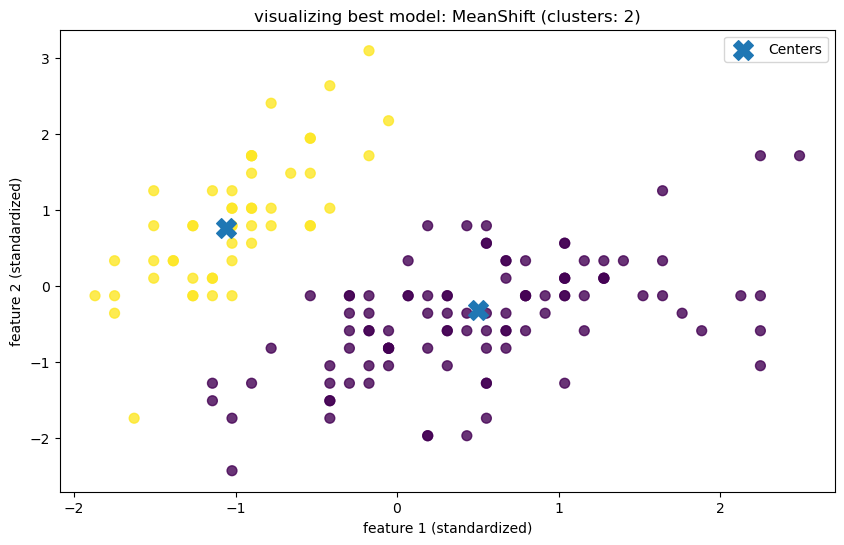

In [22]:
plt.figure(figsize=(10,6))
plt.scatter(X[: ,0],X[:,1], c=labels, cmap='viridis', s=50, alpha=0.8)
if hasattr(best_algo ,'cluster_centers_'):
    centers = best_algo. cluster_centers_


plt.scatter(centers[:,0], centers[:,1],s=200, marker='X', label='Centers')
plt.title(f'visualizing best model: MeanShift (clusters: {len(set(labels))})')
plt.xlabel('feature 1 (standardized)')
plt.ylabel('feature 2 (standardized)')
plt.legend()
plt.show()